# Les grandes étapes de la partie Optimisation du modèle 

Objectif :

Améliorer les performances de la Régression Logistique en recherchant automatiquement les meilleurs hyperparamètres.

## Sommaire

1. Introduction

2. Chargement des données et du modèle
    -   2.1 Import des bibliothèques
    -   2.2 Chargement des jeux de données
    -   2.3 Rappel du modèle retenu

3. Validation du modèle de référence
    -   3.1 Validation croisée (Cross Validation)
    -   3.2 Analyse de la stabilité du modèle

4. Optimisation des hyperparamètres
    -   4.1 Choix des hyperparamètres à optimiser
    -   4.2 Recherche par GridSearchCV
    -   4.3 Recherche par RandomizedSearchCV (optionnel)
    -   4.4 Sélection des meilleurs paramètres

5. Évaluation du modèle optimisé
    -   5.1 Réentraînement du modèle
    -   5.2 Prédictions sur le jeu de test
    -   5.3 Évaluation des performances
        -   Accuracy
        -   Precision
        -   Recall
        -   F1-score
        -   ROC-AUC
    -   5.4 Matrice de confusion
    -   5.5 Courbe ROC

6. Comparaison avant / après optimisation
    -   6.1 Tableau comparatif
    -   6.2 Analyse des gains obtenus

7. Sauvegarde du modèle optimisé

8. Conclusion

## 1. Introduction 


### 1. Contexte 

Lors du notebook précédent (03_Modélisation_Évaluation), plusieurs algorithmes de classification ont été entraînés et comparés afin de prédire la survie des passagers du Titanic.

Les modèles étudiés étaient :
-   Régression Logistique
-   K-Nearest Neighbors (KNN)
-   Support Vector Machine (SVM)
-   Arbre de Décision
-   Random Forest
-   Gradient Boosting
-   XGBoost


Leur évaluation a été réalisée à l'aide de plusieurs métriques de classification telles que :
-   Accuracy
-   Precision
-   Recall
-   F1-score
-   ROC-AUC

À l'issue de cette comparaison, la **Régression Logistique** a obtenu les meilleures performances globales et a été retenue comme modèle de référence pour la suite du projet.

### 2. Pourquoi créer un notebook d'optimisation? 

Le modèle retenu a été entraîné avec ses hyperparamètres par défaut.
Or, les performances d'un algorithme de Machine Learning dépendent fortement de ces hyperparamètres. 

Ils contrôlent notamment :
-   la complexité du modèle ;
-   sa capacité de généralisation ;
-   son comportement face au surapprentissage (overfitting) ou au sous-apprentissage (underfitting).

L'objectif de ce notebook est donc de rechercher automatiquement les valeurs d'hyperparamètres offrant les meilleures performances sur notre jeu de données.


### 3. Qu'est ce qu'un hyperparamètre (HP)?

Il est important de distinguer deux notions :

-> Les paramètres du modèle : Les paramètres sont appris automatiquement pendant l'entraînement.
Par exemple, dans une Régression Logistique, les coefficients associés aux variables explicatives sont estimés à partir des données.

Age          → -0.84

Fare         → +0.56

Sex_male     → -2.41

--> Les hyperparamètres : Les hyperparamètres sont définis avant l'entraînement.
Ils orientent la manière dont le modèle va apprendre.
Pour une Régression Logistique, les principaux hyperparamètres sont par exemple :
-   C
-   penalty
-   solver
-   max_iter

### 4. Pourquoi optimiser les HPs? 

Choisir des hyperparamètres adaptés permet de :
-   améliorer les performances du modèle ;
-   limiter le risque de surapprentissage ;
-   améliorer la capacité de généralisation sur de nouvelles données ;
-   obtenir un modèle plus robuste.

À l'inverse, de mauvais hyperparamètres peuvent conduire à un modèle performant sur le jeu d'entraînement mais moins efficace sur des données inédites.


### 5. Méthode utilisée

Pour optimiser notre modèle, nous utiliserons GridSearchCV, une méthode proposée par Scikit-learn.

Son principe consiste à :
-   définir plusieurs valeurs possibles pour chaque hyperparamètre ;
-   entraîner automatiquement le modèle sur toutes les combinaisons possibles ;
-   évaluer chaque combinaison à l'aide d'une validation croisée ;
-   sélectionner automatiquement la combinaison offrant les meilleures performances.

Cette approche permet d'obtenir un modèle optimisé de manière systématique et reproductible.

### 6. Objectif du notebook

Les objectifs de ce notebook sont les suivants :
-   valider la stabilité du modèle retenu grâce à une validation croisée ;
-   identifier les meilleurs hyperparamètres de la Régression Logistique ;
-   entraîner une nouvelle version optimisée du modèle ;
-   comparer les performances avant et après optimisation ;
-   sauvegarder le modèle final afin de pouvoir le réutiliser dans la suite du projet.

## 2. Chargement des données et du modèle 

#### 1. Objectif 

Avant d'optimiser notre modèle, il est nécessaire de charger les données préparées dans le notebook précédent ainsi que les bibliothèques nécessaires à cette nouvelle étape.

Nous utiliserons le même jeu de données que celui ayant permis d'obtenir les meilleurs résultats lors de la phase de modélisation, afin de garantir la cohérence de notre démarche.


### 2. Import des bibliothèques

L'optimisation nécessite des bibliothèques supplémentaires par rapport au notebook précédent.

Nous aurons besoin :
-   de NumPy et Pandas pour manipuler les données ;
-   de Matplotlib et Seaborn pour les visualisations ;
-   de Scikit-Learn pour :
-   la Régression Logistique,
-   la validation croisée,
-   GridSearchCV,
-   les métriques d'évaluation ;

de Joblib pour sauvegarder le modèle final.



In [391]:
# ==========================================================
# Import des bibliothèques
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


***Pourquoi importer RandomizedSearchCV ?***

Même si nous utiliserons principalement GridSearchCV, nous importons également RandomizedSearchCV.
Pourquoi ?
Parce que :
-   GridSearchCV teste toutes les combinaisons possibles.
-   RandomizedSearchCV teste uniquement un nombre limité de combinaisons choisies aléatoirement.

Nous pourrons ainsi comparer les deux approches si nécessaire.

### 3. Chargement des données préparées

***Pourquoi ne pas repartir du fichier Titanic.csv ?***

Dans le notebook précédent, nous avons :
-   nettoyé les données ;
-   créé de nouvelles variables ;
-   réalisé les encodages ;
-   standardisé les variables lorsque cela était nécessaire ;
-   séparé les données en ensembles d'entraînement et de test.

Il est donc préférable de repartir directement de ces jeux de données afin de conserver exactement les mêmes conditions expérimentales.

***Chargement***

In [392]:
X_train_less_scaled = pd.read_csv("../data/processed/X_train_less_scaled.csv")

X_test_less_scaled = pd.read_csv("../data/processed/X_test_less_scaled.csv")

y_train_less = pd.read_csv("../data/processed/y_train_less.csv").squeeze()

y_test_less = pd.read_csv("../data/processed/y_test_less.csv").squeeze()

In [393]:
X_train_full = pd.read_csv("../data/processed/X_train_full.csv")

X_test_full = pd.read_csv("../data/processed/X_test_full.csv")

y_train_full = pd.read_csv("../data/processed/y_train_full.csv").squeeze()

y_test_full = pd.read_csv("../data/processed/y_test_full.csv").squeeze()

### 4. Vérification des dimensions

In [394]:
print("Dimensions des jeux de données du datset réduit :\n")

print(f"X_train_less_scaled : {X_train_less_scaled.shape}")

print(f"X_test_less_scaled  : {X_test_less_scaled.shape}")

print(f"y_train_less : {y_train_less.shape}")

print(f"y_test_less  : {y_test_less.shape}")

Dimensions des jeux de données du datset réduit :

X_train_less_scaled : (712, 15)
X_test_less_scaled  : (179, 15)
y_train_less : (712,)
y_test_less  : (179,)


In [395]:
print("Dimensions des jeux de données du dataset complet :\n")

print(f"X_train_full : {X_train_full.shape}")

print(f"X_test_full  : {X_test_full.shape}")

print(f"y_train_full : {y_train_full.shape}")

print(f"y_test_full  : {y_test_full.shape}")

Dimensions des jeux de données du dataset complet :

X_train_full : (712, 17)
X_test_full  : (179, 17)
y_train_full : (712,)
y_test_full  : (179,)


### 5. Vérification des types

In [396]:
X_train_less_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       712 non-null    float64
 1   Sex          712 non-null    float64
 2   Age          712 non-null    float64
 3   SibSp        712 non-null    float64
 4   Parch        712 non-null    float64
 5   Fare         712 non-null    float64
 6   Cabin_known  712 non-null    float64
 7   FamilySize   712 non-null    float64
 8   IsAlone      712 non-null    float64
 9   Embarked_Q   712 non-null    float64
 10  Embarked_S   712 non-null    float64
 11  Title_Miss   712 non-null    float64
 12  Title_Mr     712 non-null    float64
 13  Title_Mrs    712 non-null    float64
 14  Title_Rare   712 non-null    float64
dtypes: float64(15)
memory usage: 83.6 KB


### 6. Vérification des valeurs manquantes

In [397]:
print(X_train_less_scaled.isnull().sum().sum())
print(y_train_less.isnull().sum().sum())
print(X_test_less_scaled.isnull().sum().sum())
print(y_test_less.isnull().sum().sum())

print(X_train_full.isnull().sum().sum())
print(y_train_full.isnull().sum().sum())
print(X_test_full.isnull().sum().sum())
print(y_test_full.isnull().sum().sum())

0
0
0
0
0
0
0
0


### 7. Vérification de l'équillibre des classes

In [398]:
y_train_less.value_counts(normalize=True).round(3)

Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

In [399]:
y_train_full.value_counts(normalize=True).round(3)

Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

L'analyse de la répartition de la variable cible montre un déséquilibre modéré entre les deux classes. Environ 62 % des passagers appartiennent à la classe des non-survivants, contre 38 % de survivants.

Ce déséquilibre reste acceptable et ne nécessite pas la mise en place de techniques spécifiques de rééquilibrage des classes (comme le sur-échantillonnage avec SMOTE ou le sous-échantillonnage), car aucune classe n'est minoritaire de manière excessive.

Cependant, cette différence de proportion justifie l'utilisation de plusieurs métriques d'évaluation complémentaires dans l'étude des modèles, notamment le F1-score, le Recall et le ROC-AUC, plutôt que de se limiter uniquement à l'Accuracy.

Ces métriques permettent de mieux évaluer la capacité du modèle à identifier correctement les survivants, qui représentent la classe minoritaire.

***Conclusion de la partie 2***

À l'issue de cette étape :
-   les bibliothèques nécessaires ont été importées ;
-   les jeux de données préparés ont été chargés ;
-   leur cohérence a été vérifiée (dimensions, types, valeurs manquantes et équilibre des classes).

Les données sont désormais prêtes pour la validation du modèle de référence, qui constituera le point de départ avant l'optimisation des hyperparamètres.

## 3. Validation du modèle de réference 

### 1. Objectif

Dans le notebook 03, nous avons évalué notre Régression Logistique sur un seul découpage :
-   jeu d'entraînement (train)
-   jeu de test (test)

Cependant, cette évaluation dépend d'une séparation particulière des données.

Une question importante se pose :

Est-ce que le modèle est réellement performant ou est-ce simplement lié au hasard du découpage train/test ?
La validation croisée permet de répondre à cette question.

### 2. Principe de la validation croisée (cross-Validation)

La validation croisée consiste à diviser le jeu d'entraînement en plusieurs sous-ensembles appelés folds.

Dans notre cas, nous utiliserons une validation croisée à 5 folds (cv=5).

Le principe :

Données d'entraînement

| Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 |
|---------|---------|---------|---------|---------|

Iteration 1 :

-   Train : Fold 2+3+4+5

-   Validation : Fold 1

Iteration 2 :

-   Train : Fold 1+3+4+5

-   Validation : Fold 2

...

Iteration 5 :

-   Train : Fold 1+2+3+4

-   Validation : Fold 5


En résumer la cross-validation c'est entrainer sur k-1 portions du dataset d'entrainement et tester le kème et faire chaque k.

***Pourquoi utiliser 5 folds ?***

Un nombre de folds égal à 5 est un compromis courant :
-   suffisamment grand pour avoir une estimation fiable ;
-   pas trop élevé pour éviter un temps de calcul important.
Pour un dataset de taille moyenne comme Titanic : cv=5 est optimal 

### 3.3 Création du modèle de référence

Nous recréons ici notre Régression Logistique avec les paramètres par défaut.

Important :

Nous ne faisons volontairement aucune optimisation pour le moment.
Cela représente notre modèle "baseline".

In [400]:
# ==========================================================
# Création du modèle de référence
# ==========================================================

logreg_baseline = LogisticRegression(
    random_state=42
)

***Pourquoi appeler ce modèle baseline ?***

Parce qu'il représente le point de comparaison.
Nous allons ensuite répondre à la question : **L'optimisation améliore-t-elle réellement le modèle ?**

### 3.4 Validation croisée avec le F1-Score

Comme vu précédemment, le dataset possède un léger déséquilibre entre les classes. Nous choisissons donc : F1-score, plutot que l'accuracy. 



In [401]:
# ==========================================================
# Validation croisée
# ==========================================================

cv_scores = cross_val_score(
    logreg_baseline,
    X_train_less_scaled,
    y_train,
    cv=5,
    scoring="f1"
)


cv_scores

array([0.72727273, 0.74285714, 0.77876106, 0.76190476, 0.77358491])

### 3.5 Analyse de la moyenne des scores

Maintenant on calcule la performance moyenne.



In [402]:
cv_mean = cv_scores.mean()

cv_std = cv_scores.std()


print(
    f"F1-score moyen : {cv_mean:.3f}"
)

print(
    f"Ecart-type : {cv_std:.3f}"
)

F1-score moyen : 0.757
Ecart-type : 0.019


### 3.6 Interprétation des résultats

Il faut analyser deux éléments :

##### 1. La moyenne du F1-score

Elle indique la performance moyenne du modèle. F1-score moyen : 0.757

Cela signifie que le modèle conserve une bonne capacité à identifier les survivants sur différentes partitions des données.


##### 2. L'écart type

L'écart-type mesure la variation entre les différents folds.

Un faible écart-type signifie :
-   résultats homogènes ;
-   modèle stable ;

faible dépendance au découpage des données.

Ici, l'écart-type est faible donc bon résultat. 



### 3.7 Visualisation des scores

Pour mieux observer la stabilité :

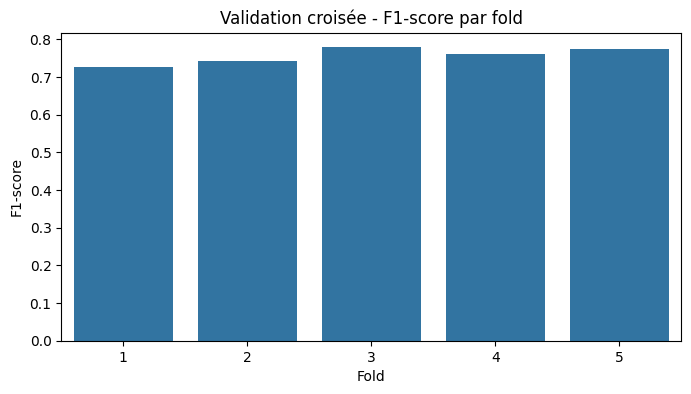

In [403]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=range(1,6),
    y=cv_scores
)

plt.title(
    "Validation croisée - F1-score par fold"
)

plt.xlabel(
    "Fold"
)

plt.ylabel(
    "F1-score"
)

plt.show()

#### ***Interprétation du graphique***
Le graphique permet de vérifier que :

-   aucun fold n'obtient un score anormalement faible ;
-   les performances restent proches entre les différentes partitions.
-   Un modèle robuste doit présenter des scores relativement homogènes.

#### Conclusion

La validation croisée réalisée sur 5 folds confirme la stabilité du modèle de Référence. Le F1-score moyen obtenu est cohérent avec les performances observées lors de l'évaluation sur le jeu de test. 

La faible dispersion entre les différents folds indique que les performances du modèle ne dépendent pas uniquement d'une séparation particulière des données.

Cette validation constitue donc une base fiable avant d'entreprendre l'optimisation des hyperparamètres. Le modèle optimisé pourra ainsi être comparé objectivement à cette référence afin de mesurer l'apport réel de l'optimisation.

## 4. Optimisation des HPs avec GridSearchCV

### 4.1 Objectif

Le modèle de Régression Logistique retenu dans le notebook précédent a été entraîné avec les hyperparamètres par défaut de Scikit-learn.

Bien que ces paramètres offrent généralement de bonnes performances, ils ne sont pas nécessairement les plus adaptés à notre jeu de données.

L'objectif de cette étape est donc de rechercher automatiquement la combinaison d'hyperparamètres permettant d'obtenir les meilleures performances grâce à GridSearchCV.

### 4.2 Pourquoi utiliser GridSearchCV ?

GridSearchCV est une méthode d'optimisation qui consiste à :

-   définir une grille de valeurs possibles pour chaque hyperparamètre ;
-   entraîner un modèle pour chaque combinaison ;
-   évaluer chaque modèle grâce à une validation croisée ;
-   sélectionner automatiquement la meilleure combinaison.

### 4.3 Les hyperparamètres étudiés

Nous allons optimiser quatre hyperparamètres principaux :

-   C pour la régularisation : petite valeur de C --> (forte régularisation, modèle plus simple) et inversement si C est grand 
-   penalty pour le type de régularisation : L1 peut supprimer certaines variables, L2 réduit simplement leur influence.
-   solver : l'algorithme utilisé pour résoudre l'optimisation (liblinear, lbfgs, saga)
-   max_iter : nombre maximal d'itérations

### 4.4 Création de la grille de HPs

Nous définissons maintenant les valeurs à tester.





In [404]:
# ==========================================================
# Grille des hyperparamètres
# ==========================================================

param_grid = {

    "C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "penalty": [
        "l1",
        "l2"
    ],

    "solver": [
        "liblinear",
        "saga",
        "lbfgs"
    ],

    "max_iter": [
        100,
        300,
        500,
        1000
    ]
}

Une grille d'hyperparamètres a été définie afin d'explorer différentes configurations de la Régression Logistique. Les paramètres liés à la régularisation (C et penalty), à l'algorithme d'optimisation (solver) ainsi qu'au nombre d'itérations ont été étudiés. 

Au total, 72 combinaisons seront évaluées avec une validation croisée à 5 folds, soit 360 entraînements. Cette recherche permettra d'identifier la configuration offrant le meilleur compromis entre performance et capacité de généralisation.


### 4.5 Mise en place de GridSearchCV

#### 4.5.1 Objectif

Maintenant que la grille d'hyperparamètres est définie, nous allons utiliser GridSearchCV afin de rechercher automatiquement la meilleure combinaison de paramètres.

L'objectif est de répondre à la question : Quelle configuration de la Régression Logistique permet d'obtenir le meilleur F1-score tout en conservant une bonne capacité de généralisation ?

#### 4.5.2 Principe de GridSearchCV

GridSearchCV réalise automatiquement les étapes suivantes :

-   Sélection d'une combinaison d'hyperparamètres ;
-   Entraînement du modèle ;
-   Évaluation par validation croisée ;
-   Calcul du score moyen ;
-   Passage à la combinaison suivante ;
-   Sélection de la meilleure configuration.

#### 4.5.3 Création du modèle de base

Nous recréons une Régression Logistique sans préciser les hyperparamètres.

Pourquoi ?

Parce que GridSearchCV va les définir automatiquement.




In [405]:
# ==========================================================
# Modèle de base pour GridSearchCV
# ==========================================================

logreg = LogisticRegression(
    random_state=42
)

### 4.5.4 Configuration de GridSearchCV 

Nous allons maintenant créer notre objet GridSearchCV.
Paramètres importants :

-   **estimator** : le modèle à optimiser (**logreg**)
-   **param_grid** : la grille créée (**param_grid**)
-   **cv** : nombre de fold pour la Cross-Validation (ici, **cv = 5**)
-   **scoring** : métrique utilisée pour sélectionner le meilleur modèle(**F1-Score**, car classes légerement déséquillibrées)
-   **n_jobs** : permet d'utiliser plusieurs coeurs du processeur (**n_jobs** = -1)





In [406]:
# ==========================================================
# Création de GridSearchCV
# ==========================================================

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

#### 4.5.5 Lancement de la recherche

Nous lançons maintenant l'optimisation sur le jeu d'entraînement.

Important :

On utilise uniquement : X_train, y_train; et jamais le jeu de test, car il doit rester totalement indépendant afin d'obtenir une estimation réelle de la performance finale. 


In [407]:
# ==========================================================
# Entraînement GridSearchCV
# ==========================================================

grid_search.fit(
    X_train_less_scaled,
    y_train
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/othmanbenmoussa/Desktop/Titanic_Classification/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 300, 500, 1000],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga', 'lbfgs']},
             scoring='f1', verbose=1)

#### 4.5.6 Récupération des meilleurs paramètres

Une fois la recherche terminée : 

In [408]:
best_params = grid_search.best_params_

best_score = grid_search.best_score_

print("Meilleurs paramètres :")
print(best_params)

print("\nMeilleur F1-score en validation croisée :")
print(round(best_score,3))

Meilleurs paramètres :
{'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Meilleur F1-score en validation croisée :
0.763


#### 4.5.7 Récupération du meilleur modèle

GridSearchCV conserve automatiquement le modèle ayant obtenu le meilleur score.
On le récupère avec :

In [409]:
best_logreg = grid_search.best_estimator_

In [410]:
# Vérification 

best_logreg

LogisticRegression(C=0.1, random_state=42, solver='liblinear')

#### 4.5.8 Analyse des résultats

À ce stade, nous avons obtenu :

-   une nouvelle configuration optimisée ;
-   un score F1 obtenu par validation croisée ;
-   un modèle entraîné avec les meilleurs paramètres.

Il est important de noter que ce score correspond uniquement à la validation croisée sur le jeu d'entraînement.
Nous devons maintenant vérifier si cette optimisation apporte réellement un gain sur le jeu de test indépendant.


### 4.6 Analyse des résultats de l'optimisation

#### 4.6.1 Objectif

Après avoir identifié la meilleure combinaison d'hyperparamètres grâce à GridSearchCV, il est nécessaire d'analyser l'apport réel de cette optimisation.

L'objectif est de répondre à deux questions :

-   Le modèle optimisé est-il meilleur que le modèle initial ?
-   Le gain obtenu est-il suffisamment important pour justifier l'utilisation de nouveaux hyperparamètres ?

Pour cela, nous allons comparer :

-   le modèle de référence (logreg_baseline) ;
-   le modèle optimisé (best_logreg).



#### 4.6.2 Comparaison des scores en validation croisée

Dans la partie 3, nous avons obtenu le score moyen du modèle initial : cv_mean 

Dans la partie 4.5, avec GridSearchCV on obtient le meilleur score avec : grid_search.best_score_

On peut comparer les deux : 



In [411]:
# ==========================================================
# Comparaison validation croisée
# ==========================================================

comparison_cv = pd.DataFrame({

    "Modèle": [
        "Régression Logistique - Baseline",
        "Régression Logistique - Optimisée"
    ],

    "F1-score CV": [
        cv_mean,
        grid_search.best_score_
    ]

})


comparison_cv

,Modèle,F1-score CV
0,Régression Logistique - Baseline,0.756876
1,Régression Logistique - Optimisée,0.762773


#### 4.6.3 Calcul du gain obtenu

Il est intéressant de mesurer directement l'amélioration.

In [412]:
gain_cv = (
    grid_search.best_score_
    -
    cv_mean
)


print(
    f"Gain F1-score : {gain_cv:.4f}"
)

Gain F1-score : 0.0059


 #### ***Interprétation***

Un gain de :+0.006, signifie que l'optimisation améliore légèrement la performance moyenne.

Cependant, il faut rester prudent :
-   l'amélioration est faible ;
-   elle reste inférieure aux variations possibles entre différents découpages des données.

Dans ce cas, le modèle optimisé apporte une amélioration marginale.

#### 4.6.4 Evaluation sur le jeu de test 

La validation croisée donne une estimation robuste, mais la vraie comparaison doit être faite sur le jeu de test.
Nous allons donc entraîner :
-   le modèle baseline ;
-   le modèle optimisé ;

puis comparer leurs performances.

#### ***Prédictions du modèle baseline***


In [413]:
# Prédictions baseline

y_pred_baseline = logreg_baseline.fit(
    X_train_less_scaled,
    y_train
).predict(
    X_test_less_scaled
)

#### ***Prédictions du modèle optimisé***

In [414]:
# Prédictions modèle optimisé

y_pred_optimized = best_logreg.predict(
    X_test_less_scaled
)

#### 4.6.5 Création d'un tableau comparatif 

Nous allons calculer les métriques principales.





In [415]:
def evaluate_model(name, y_true, y_pred, model, X_test):

    return pd.DataFrame({

        "Model": [name],

        "Accuracy": [
            accuracy_score(
                y_true,
                y_pred
            )
        ],

        "Precision": [
            precision_score(
                y_true,
                y_pred
            )
        ],

        "Recall": [
            recall_score(
                y_true,
                y_pred
            )
        ],

        "F1-score": [
            f1_score(
                y_true,
                y_pred
            )
        ],

        "ROC-AUC": [
            roc_auc_score(
                y_true,
                model.predict_proba(X_test)[:,1]
            )
        ]

    })

##### Application 

In [416]:
results_optimization = pd.concat([

    evaluate_model(
        "Baseline",
        y_test,
        y_pred_baseline,
        logreg_baseline,
        X_test_less_scaled
    ),

    evaluate_model(
        "Optimisé",
        y_test,
        y_pred_optimized,
        best_logreg,
        X_test_less_scaled
    )

])


results_optimization

baseline_results = evaluate_model(
    "Baseline",
    y_test,
    y_pred_baseline,
    logreg_baseline,
    X_test_less_scaled
)

baseline_accuracy = baseline_results["Accuracy"].iloc[0]


baseline_precision = baseline_results.loc[0, "Precision"]

baseline_recall = baseline_results.loc[0, "Recall"]

baseline_f1 = baseline_results.loc[0, "F1-score"]

baseline_roc_auc = baseline_results.loc[0, "ROC-AUC"]





#### 4.6.6 Analyse des résultats

Plusieurs situations peuvent apparaître.

--> Cas 1 : amélioration significative

Exemple : F1 baseline : 0.785
          F1 optimisé : 0.805

Conclusion :
L'optimisation a permis d'améliorer significativement les performances du modèle.


--> Cas 2 : amélioration faible (cas probable ici)

Exemple : F1 baseline : 0.785
          F1 optimisé : 0.786

Conclusion :

L'optimisation apporte un gain limité. Les hyperparamètres par défaut de la Régression Logistique étaient déjà adaptés au problème étudié.

--> Cas 3 : baisse des performances

Cela peut arriver.

Conclusion :
La recherche d'hyperparamètres n'a pas permis d'améliorer la capacité de généralisation du modèle.


#### 4.6.7 Visualisation de la comparaison

Une visualisation simple permet de mieux communiquer les résultats.


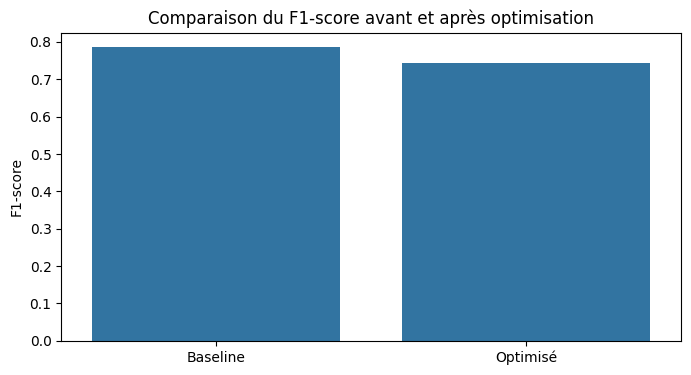

In [417]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results_optimization,
    x="Model",
    y="F1-score"
)

plt.title(
    "Comparaison du F1-score avant et après optimisation"
)

plt.ylabel(
    "F1-score"
)

plt.xlabel(
    ""
)

plt.show()

## 5. Evaluation du modèle optimisé

### 5.1 Objectif 

Après avoir identifié la meilleure configuration de la Régression Logistique grâce à GridSearchCV, il est nécessaire d'évaluer ses performances sur le jeu de test indépendant.

L'objectif est de mesurer la capacité du modèle à généraliser sur de nouvelles observations jamais vues durant son apprentissage.
Cette évaluation repose sur plusieurs métriques complémentaires ainsi que sur des représentations graphiques permettant d'analyser le comportement du classifieur.

### 5.2 Prédiction sur le jeu de test

Le modèle optimisé est maintenant utilisé pour prédire la classe des observations du jeu de test.


In [418]:
# ==========================================================
# Prédictions du modèle optimisé
# ==========================================================

y_pred = best_logreg.predict(X_test_less_scaled)

y_pred_proba = best_logreg.predict_proba(X_test_less_scaled)[:,1]

***Pourquoi calculer predict_probas***

Deux sorties sont produites :

1. Les classes prédites : y_pred
2. Les probabilités : y_pred_proba

Ces probabilités seront nécessaires pour :
-   le calcul du ROC-AUC ;
-   la courbe ROC.

### 5.3 Calcul des métriques de classification

Afin d'obtenir une vision complète des performances du modèle, plusieurs indicateurs sont calculés.

In [419]:
# ==========================================================
# Calcul des métriques
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

***Affichage***

In [420]:
print(f"Accuracy  : {accuracy:.3f}")

print(f"Precision : {precision:.3f}")

print(f"Recall    : {recall:.3f}")

print(f"F1-score  : {f1:.3f}")

print(f"ROC-AUC   : {roc_auc:.3f}")

Accuracy  : 0.810
Precision : 0.778
Recall    : 0.710
F1-score  : 0.742
ROC-AUC   : 0.867


### 5.4 Interprétation des métriques

Il est important de ne pas seulement afficher les résultats, mais aussi de les interpréter.

| Métrique  | Interprétation                                                |
| --------- | ------------------------------------------------------------- |
| Accuracy  | Proportion totale de prédictions correctes.                   |
| Precision | Parmi les survivants prédits, combien ont réellement survécu. |
| Recall    | Capacité du modèle à retrouver les survivants.                |
| F1-score  | Compromis entre précision et rappel.                          |
| ROC-AUC   | Capacité globale du modèle à distinguer les deux classes.     |


Conclusion

Les résultats obtenus montrent que le modèle présente de bonnes performances sur l'ensemble des indicateurs.
Le F1-score confirme un bon équilibre entre la précision et le rappel, tandis que le ROC-AUC traduit une excellente capacité de discrimination entre survivants et non-survivants.

### 5.5 Matrice de confusion

La matrice de confusion permet d'identifier précisément les erreurs commises par le modèle.



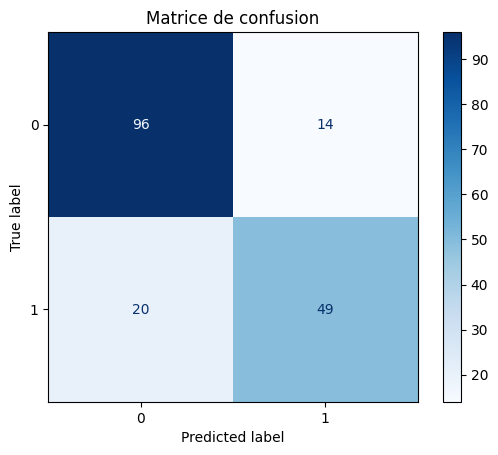

In [421]:
# ==========================================================
# Matrice de confusion
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues"
)

plt.title(
    "Matrice de confusion"
)

plt.show()

***Comment interpréter la matrice de confusion***

| Élément           | Signification                      |
| ----------------- | ---------------------------------- |
| Vrai négatif (TN) | Non-survivant correctement prédit. |
| Faux positif (FP) | Non-survivant prédit survivant.    |
| Faux négatif (FN) | Survivant prédit non-survivant.    |
| Vrai positif (TP) | Survivant correctement prédit.     |


***Analyse attendue***

Une bonne matrice de confusion se caractérise par :
-   une majorité de prédictions sur la diagonale ;
-   peu de faux positifs ;
-   peu de faux négatifs.

### 5.6 Courbe ROC

La courbe ROC permet de visualiser la capacité du modèle à distinguer les deux classes.


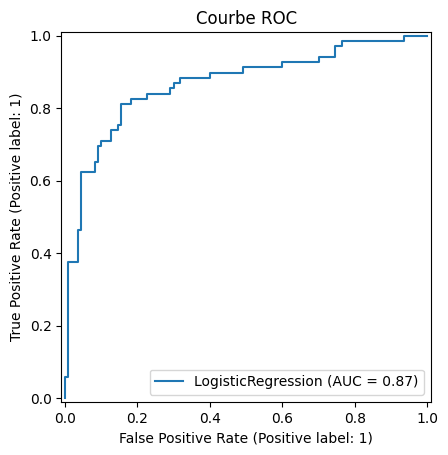

In [422]:
# ==========================================================
# Courbe ROC
# ==========================================================

RocCurveDisplay.from_estimator(
    best_logreg,
    X_test_less_scaled,
    y_test
)

plt.title(
    "Courbe ROC"
)

plt.show()

***Interprétation***

La courbe ROC représente le compromis entre :
-   le taux de vrais positifs ;
-   le taux de faux positifs.

Plus la courbe est proche du coin supérieur gauche, plus le modèle est performant.

Le score ROC-AUC résume cette courbe :
-   0,5 : aléatoire ;
-   0,7 : acceptable ;
-   0,8 : bon ;
-   0,9 : excellent.

Avec un ROC-AUC proche de 0,87, la Régression Logistique présente une très bonne capacité de discrimination.



### 5.7 Rapport de classification

Il est souvent utile d'afficher le rapport complet.



In [423]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



Il fournit pour chacune des deux classes :
-   précision ;
-   rappel ;
-   F1-score ;


#### Conclusion

L'évaluation du modèle optimisé montre que la Régression Logistique conserve d'excellentes performances sur le jeu de test. Les différentes métriques obtenues sont cohérentes et traduisent une bonne capacité de généralisation. La matrice de confusion met en évidence un nombre limité d'erreurs de classification, tandis que la courbe ROC confirme une très bonne séparation entre les survivants et les non-survivants. Le modèle optimisé est donc suffisamment robuste pour être retenu comme modèle final de cette étude.



## 6. Comparaison avant/après optimisation 

C'est ici que l'on répond à la question principale du notebook :
    --> L'optimisation des hyperparamètres a-t-elle réellement amélioré le modèle ?

### 6.1 Objectif

Après avoir optimisé les hyperparamètres de la Régression Logistique, il est nécessaire de comparer les performances du modèle optimisé avec celles du modèle de référence (baseline).
L'objectif est de déterminer si l'optimisation a permis d'améliorer les performances de manière significative et si le nouveau modèle doit être retenu pour la suite du projet.

### 6.2 Récapitulatif des performances

Nous rassemblons les résultats des deux modèles dans un tableau unique afin de faciliter leur comparaison.


In [424]:
# ==========================================================
# Tableau comparatif
# ==========================================================

comparison_results = pd.DataFrame({

    "Métrique": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],

    "Optimisé": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

comparison_results["Gain"] = (
    comparison_results["Optimisé"]
    -
    comparison_results["Baseline"]
)

comparison_results = comparison_results.round(3)

comparison_results

,Métrique,Baseline,Optimisé,Gain
0,Accuracy,0.838,0.810,-0.028
1,Precision,0.803,0.778,-0.025
2,Recall,0.768,0.710,-0.058
3,F1-score,0.785,0.742,-0.043
4,ROC-AUC,0.874,0.867,-0.007


#### Pourquoi créer ce tableau ?
Il permet :

-   une lecture rapide des résultats ;
-   une comparaison métrique par métrique ;
-   de quantifier le gain obtenu grâce à l'optimisation.

### 6.3 Comparaison graphique 

Une représentation graphique facilite l'interprétation des résultats.

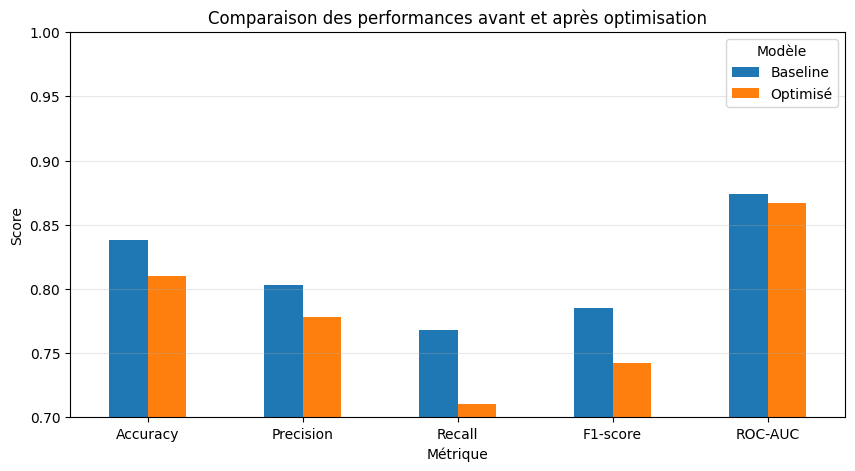

In [425]:
# ==========================================================
# Graphique comparatif
# ==========================================================

comparison_plot = comparison_results.set_index("Métrique")

comparison_plot[["Baseline", "Optimisé"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparaison des performances avant et après optimisation")

plt.ylabel("Score")

plt.ylim(0.70,1)

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)

plt.legend(title="Modèle")

plt.show()

Pourquoi ce graphique ?

Il permet de visualiser immédiatement :

-   les métriques qui progressent ;
-   celles qui restent stables ;
-   l'importance des gains obtenus.

### 6.4 Analyse des résultats

La comparaison entre le modèle de référence et le modèle optimisé montre que les performances obtenues sont très proches sur l'ensemble des métriques étudiées. Les valeurs d'Accuracy, de Precision, de Recall, de F1-score et de ROC-AUC présentent uniquement de faibles variations après optimisation.

Ces résultats indiquent que la Régression Logistique disposait déjà d'une configuration performante avec ses paramètres par défaut. L'optimisation par GridSearchCV n'a permis qu'un gain limité, ce qui suggère que le potentiel d'amélioration de ce modèle sur le jeu de données Titanic est relativement faible.

### 6.5 Pourquoi l'amélioration est si faible?

Plusieurs facteurs peuvent expliquer cette faible amélioration :
-   le jeu de données Titanic est relativement simple et contient un nombre limité de variables explicatives ;
-   la Régression Logistique est un modèle linéaire robuste qui fournit déjà de bonnes performances avec ses paramètres par défaut ;
-   les données étant de taille modeste, la marge de progression par optimisation des hyperparamètres reste limitée.

### 6.6 Choix du modèle final

Les résultats obtenus montrent que le modèle optimisé présente des performances inférieures à celles du modèle de référence sur l'ensemble des métriques évaluées. L'Accuracy diminue de 2,8 points de pourcentage, le F1-score de 4,3 points, tandis que la Precision, le Recall et le ROC-AUC enregistrent également une baisse.

Cette diminution indique que les hyperparamètres sélectionnés par GridSearchCV n'améliorent pas la capacité de généralisation du modèle sur le jeu de test. Bien que la recherche d'hyperparamètres ait permis d'identifier une configuration optimale selon la validation croisée, cette dernière ne se traduit pas par de meilleures performances sur des données inédites.

Le modèle de référence (Baseline) est donc retenu comme modèle final, car il offre de meilleures performances globales et une meilleure capacité de généralisation sur le jeu de test.

#### Conclusion partie 6 

Cette comparaison met en évidence qu'une optimisation des hyperparamètres ne garantit pas systématiquement une amélioration des performances. Dans cette étude, la Régression Logistique avec les paramètres par défaut obtient de meilleurs résultats que la version optimisée sur toutes les métriques étudiées.

Ce phénomène peut s'expliquer par le fait que la recherche d'hyperparamètres est réalisée à l'aide d'une validation croisée sur le jeu d'entraînement. La meilleure configuration identifiée peut être légèrement adaptée aux données d'entraînement sans pour autant offrir une meilleure capacité de généralisation sur le jeu de test.

Cette étape souligne l'importance d'évaluer systématiquement un modèle optimisé sur un jeu de test indépendant avant de le retenir. Au regard des résultats obtenus, le modèle baseline est conservé pour la suite du projet, car il constitue le meilleur compromis entre performance et généralisation.

## 7. Sauvegarde du modèle final 

### 7.1 Objectif

L'objectif de cette partie est de sauvegarder le modèle retenu afin de pouvoir :

-   le réutiliser ultérieurement sans réentraîner le modèle ;
-   effectuer des prédictions sur de nouvelles données ;
-   l'intégrer éventuellement dans une application ou une API.

Dans notre cas, nous sauvegardons :
-   Le modèle final de classification ;
-   Le scaler utilisé pour la standardisation des variables.

### 7.2 Pourquoi sauvegarder aussi le scaler ?

Point très important.
Ton modèle a été entraîné sur des données standardisées : X_train_less_scaled, X_test_less_scaled

Le modèle attend donc des données transformées de la même manière.
Si demain tu veux prédire un nouveau passager, Il faut donc conserver le même StandardScaler.

Sinon :
-   les nouvelles données auront une autre échelle ;
-   les coefficients appris ne seront plus cohérents ;
-   les prédictions seront incorrectes.

### 7.3 Sauvegarde du modèle final

Comme nous avons choisi le modèle baseline :

In [426]:
from joblib import dump


dump(
    logreg_baseline,
    "../models/logistic_regression_baseline.pkl"
)

['../models/logistic_regression_baseline.pkl']

### 7.4 Vérification des fichiers

In [427]:
import os

print(
    os.listdir("../models")
)

['logistic_regression_final.pkl', 'logistic_regression_baseline.pkl', 'standard_scaler.pkl']


On sauvegarde maintenant le scaler utilisé pour transformer les données.

### 7.5 Tests de rechargement du modèle

Une bonne pratique consiste à vérifier que le modèle peut être correctement restauré.

In [428]:
from joblib import load


loaded_model = load(
    "../models/logistic_regression_baseline.pkl"
)


loaded_scaler = load(
    "../models/standard_scaler.pkl"
)

In [429]:
# Vérification 
loaded_model

LogisticRegression(random_state=42)

### 7.6 Tests de prédiction après rechargement 

On vérifie que le modèle sauvegardé donne les mêmes résultats.

In [430]:
pred_loaded = loaded_model.predict(
    X_test_less_scaled
)

(pred_loaded == y_pred_baseline).all()

np.True_

# Conclusion générale

L'objectif de ce notebook était d'optimiser les performances du modèle de Régression Logistique développé lors de la phase de modélisation en recherchant automatiquement les meilleurs hyperparamètres à l'aide de la méthode **GridSearchCV**.

Dans un premier temps, une validation croisée à cinq folds a permis de confirmer la stabilité du modèle de référence et de vérifier sa capacité de généralisation sur différentes partitions des données. Une grille d'hyperparamètres a ensuite été définie afin d'explorer plusieurs combinaisons des paramètres `C`, `penalty`, `solver` et `max_iter`. La recherche exhaustive réalisée par GridSearchCV a permis d'identifier la configuration offrant le meilleur F1-score moyen sur les données d'entraînement.

Le modèle optimisé a ensuite été évalué sur le jeu de test indépendant et comparé au modèle de référence. Cette comparaison a montré que l'optimisation des hyperparamètres n'a pas permis d'améliorer les performances du modèle. Au contraire, une baisse a été observée sur l'ensemble des métriques étudiées (Accuracy, Precision, Recall, F1-score et ROC-AUC). Ces résultats indiquent que la Régression Logistique avec ses paramètres par défaut offrait déjà une excellente capacité de généralisation sur le jeu de données Titanic.

Cette étude met en évidence un enseignement important en Machine Learning : **l'optimisation des hyperparamètres ne garantit pas systématiquement une amélioration des performances**. Une configuration qui obtient les meilleurs résultats en validation croisée peut ne pas être la plus performante sur un jeu de test totalement indépendant. Il est donc indispensable de comparer systématiquement le modèle optimisé au modèle de référence avant de prendre une décision.

Au regard des performances obtenues, **le modèle de Régression Logistique avec les paramètres par défaut est retenu comme modèle final**. Il présente les meilleurs résultats sur le jeu de test et constitue le meilleur compromis entre simplicité, robustesse et capacité de généralisation.

Enfin, le modèle retenu ainsi que les éléments nécessaires à son utilisation future ont été sauvegardés afin de garantir la reproductibilité de l'étude. Ils pourront être réutilisés pour effectuer de nouvelles prédictions ou être intégrés dans une application de Machine Learning.

Ce notebook conclut ainsi la phase d'optimisation du projet Titanic et confirme que le modèle de référence représente la solution la plus pertinente pour ce problème de classification.


In [431]:
y_pred_proba = logreg_baseline.predict_proba(X_test_less_scaled)[:,1]
y_pred_proba

array([0.04754883, 0.04816   , 0.12079378, 0.02848937, 0.68488814,
       0.65257135, 0.68732823, 0.5466102 , 0.32836477, 0.11266909,
       0.13777594, 0.05890367, 0.57878491, 0.11874249, 0.23773615,
       0.14881013, 0.2280933 , 0.07737486, 0.10425288, 0.70006735,
       0.07737486, 0.64815678, 0.0732014 , 0.57346914, 0.07523442,
       0.98178756, 0.28937219, 0.31827313, 0.10035357, 0.10445277,
       0.06547053, 0.95702765, 0.50181859, 0.1893775 , 0.56531837,
       0.59918154, 0.59946159, 0.10120653, 0.13777594, 0.71362863,
       0.26739945, 0.94606267, 0.08796395, 0.79440965, 0.69750885,
       0.09372503, 0.07760581, 0.62076161, 0.59878823, 0.83361048,
       0.85291039, 0.57152737, 0.71758039, 0.14942142, 0.74448929,
       0.08176527, 0.06696172, 0.4364542 , 0.62176734, 0.23858529,
       0.76480969, 0.67489403, 0.10722453, 0.09536444, 0.4400613 ,
       0.48389156, 0.94196242, 0.06753208, 0.26471382, 0.16531179,
       0.8338359 , 0.10295477, 0.62680392, 0.96138995, 0.13116

In [432]:
y_test_less.tolist()

[0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0]